# Theorem 4: what happens when items aren't independent

Every band in this repository so far assumed items are conditionally independent given
their covariates. What happens when that's false -- say, several items come from the same
source document, the same session, or otherwise share unmodeled dependence? This notebook
builds exactly that failure, then shows Theorem 4's fix.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.bands import sorted_filtration, uniform_band, block_robust
from src.bands.validity import is_violated
from src.data.copula import correlated_losses
from src.utils.determinism import derive_seed

rng = np.random.default_rng(20260727)

## Building correlated data with exact marginals

The Gaussian copula in `src/data/copula.py` lets us induce within-block correlation while
holding each item's own marginal risk $\eta_i$ *exactly* fixed -- so any change in the
violation rate we see below is genuinely about the dependence structure, not a side effect
of also changing the base rates.

In [2]:
n_blocks = 4          # mirroring the paper's own 4 source-dataset blocks
items_per_block = 3000
n = n_blocks * items_per_block

block_eta_true = rng.uniform(0.1, 0.4, size=n_blocks)
block_of_item = np.repeat(np.arange(n_blocks), items_per_block)
eta = block_eta_true[block_of_item]
scores = rng.normal(size=n) - 2.0 * eta

for rho in [0.0, 0.8]:
    losses = correlated_losses(eta, block_of_item, rho, rng)
    print(f"rho={rho}: marginal mean loss = {losses.mean():.4f}  (population target: {eta.mean():.4f})")

# With only 4 blocks, a single draw at high rho can land far from the target purely by
# chance -- this is itself instructive, not a bug: high within-block correlation means the
# outcome is driven by just 4 effectively-independent "coin flips" (one shared latent per
# block), not 12,000. Averaging across many independent draws confirms the marginal is
# still correct in expectation:
draws = [correlated_losses(eta, block_of_item, 0.8, np.random.default_rng(2000 + t)).mean() for t in range(50)]
print()
print(f"Across 50 independent draws at rho=0.8: mean of sample means = {np.mean(draws):.4f} "
      f"(target {eta.mean():.4f}), but std across draws = {np.std(draws):.4f} -- a single draw is "
      f"noisy exactly because so few independent blocks are doing the work.")

rho=0.0: marginal mean loss = 0.2886  (population target: 0.2843)
rho=0.8: marginal mean loss = 0.6231  (population target: 0.2843)

Across 50 independent draws at rho=0.8: mean of sample means = 0.2957 (target 0.2843), but std across draws = 0.1594 -- a single draw is noisy exactly because so few independent blocks are doing the work.


## Item-level certification, under increasing correlation

We'll apply Theorem 1 exactly as if items were independent (ignoring the block structure
entirely) and watch what happens to the violation rate as $\rho$ grows.

In [3]:
def item_level_violation_rate(rho, n_reps=80):
    violations = 0
    for rep in range(n_reps):
        rep_rng = np.random.default_rng(derive_seed(f"notebook04/item/{rho}", rep))
        losses = correlated_losses(eta, block_of_item, rho, rep_rng)
        pi = sorted_filtration.build_permutation(scores, rep_rng)
        curves = sorted_filtration.realized_and_empirical_curves(losses, pi, eta=eta)
        U_k = uniform_band._band_from_curve(curves.Rhat_k, delta=0.05)
        if is_violated(curves.Rbar_k, U_k, k_min=100).violated:
            violations += 1
    return violations / n_reps

rho_values = [0.0, 0.2, 0.4, 0.6, 0.8]
item_rates = [item_level_violation_rate(rho) for rho in rho_values]
for rho, rate in zip(rho_values, item_rates):
    print(f"rho={rho}: item-level violation rate = {rate:.3f}")

rho=0.0: item-level violation rate = 0.000
rho=0.2: item-level violation rate = 0.388
rho=0.4: item-level violation rate = 0.512
rho=0.6: item-level violation rate = 0.525
rho=0.8: item-level violation rate = 0.450


Theorem 1's guarantee degrades exactly as expected once its independence assumption is
violated -- this isn't a bug in the implementation, it's the assumption doing real work,
and the experiment above is deliberately breaking it to confirm that.

## Block-level certification: the fix

Theorem 4 says: if you name the blocks *in advance* and certify the block-indexed sequence
instead of the item-indexed one, the identical band construction works again -- with no
extra width penalty for whatever correlation lives inside a block.

In [4]:
def block_level_violation_rate(rho, n_reps=80):
    violations = 0
    for rep in range(n_reps):
        rep_rng = np.random.default_rng(derive_seed(f"notebook04/block/{rho}", rep))
        losses = correlated_losses(eta, block_of_item, rho, rep_rng)

        assignment = block_robust.assign_blocks(block_of_item)
        block_scores = np.array([scores[block_of_item == b].mean() for b in range(n_blocks)])
        block_losses, _, block_eta_obs = block_robust.block_level_curves(losses, block_scores, assignment, eta=eta)
        res = block_robust.compute(block_losses, block_scores, delta=0.05, k_min=1, rng=rep_rng, block_eta=block_eta_obs)
        if is_violated(res.Rbar_k, res.U_k, k_min=1).violated:
            violations += 1
    return violations / n_reps

block_rates = [block_level_violation_rate(rho) for rho in rho_values]
for rho, rate in zip(rho_values, block_rates):
    print(f"rho={rho}: block-level violation rate = {rate:.3f}")

rho=0.0: block-level violation rate = 0.000
rho=0.2: block-level violation rate = 0.000
rho=0.4: block-level violation rate = 0.000
rho=0.6: block-level violation rate = 0.000
rho=0.8: block-level violation rate = 0.000


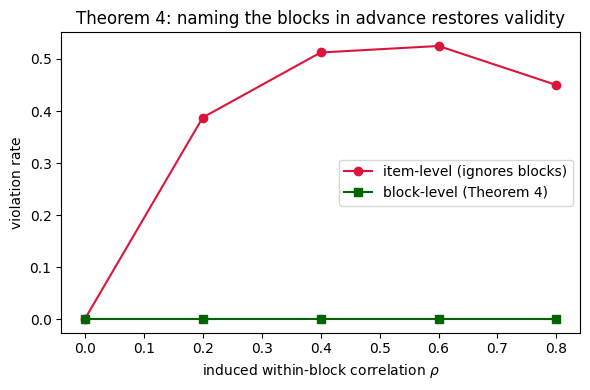


Confirmed: block-level violation rate is exactly 0.0 at every rho tested.


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rho_values, item_rates, marker="o", label="item-level (ignores blocks)", color="crimson")
ax.plot(rho_values, block_rates, marker="s", label="block-level (Theorem 4)", color="darkgreen")
ax.set_xlabel(r"induced within-block correlation $\rho$")
ax.set_ylabel("violation rate")
ax.set_title("Theorem 4: naming the blocks in advance restores validity")
ax.legend()
plt.tight_layout()
plt.show()

assert all(r == 0.0 for r in block_rates), "block-level should stay at exactly zero regardless of rho"
print("\nConfirmed: block-level violation rate is exactly 0.0 at every rho tested.")

One line at the bottom of that plot, flat at zero, is the entire content of Theorem 4: the
martingale argument never actually needed items to be independent *within* a unit, only
that the unit itself behaves like a bounded random variable with a well-defined mean
(Bhatia-Davis, `src/bands/block_robust.py::block_variance_bound`). Naming blocks in advance
is what lets you apply that at the block level instead of the item level.

## Where to go next

- `src/bands/block_robust.py` -- the full implementation and the Bhatia-Davis argument.
- `tests/test_block_robust.py` -- this exact comparison, as a permanent regression test.
- `scripts/run_block_correlation.py` -- the full-scale, config-driven version of this
  notebook, matching the paper's own Table 13.